In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
X = pd.DataFrame(data['data'])
y = pd.DataFrame(data['target'])

<Axes: >

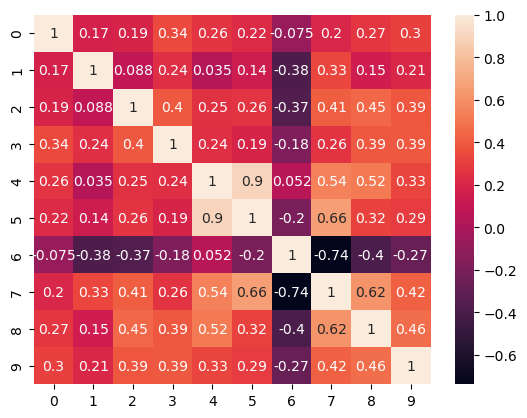

In [4]:
sns.heatmap(X.corr(),annot=True)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=14)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print(f"R2 Score: {r2_score(y_test,y_pred)}")

R2 Score: 0.5002472361041004


In [7]:
lr.coef_

array([[  44.19355716, -240.02129399,  490.28738283,  331.88852968,
        -785.79400259,  487.64421138,   35.19787855,  112.93618404,
         727.171488  ,   91.00554753]])

In [8]:
class MultipleRegression():
    def __init__(self):
        self.weights_ = None
        self.bias_ = None

    def rmse(self,y_actual, y_pred):
        e = y_actual-y_pred
        return np.sqrt(np.transpose(e)*e)

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)

        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        
        self.bias_ = betas[0]
        self.weights_ = betas[1:]

    def predict(self,X_test):
        return np.dot(X_test,self.weights_) + self.bias_

In [9]:
mr = MultipleRegression()
mr.fit(X_train,y_train)
y_pred = mr.predict(X_test)
print(f"R2 Score: {r2_score(y_test,y_pred)}")

R2 Score: 0.5002472361041004


In [10]:
mr.weights_

array([[  44.19355716],
       [-240.02129399],
       [ 490.28738283],
       [ 331.88852968],
       [-785.79400259],
       [ 487.64421138],
       [  35.19787855],
       [ 112.93618404],
       [ 727.171488  ],
       [  91.00554753]])

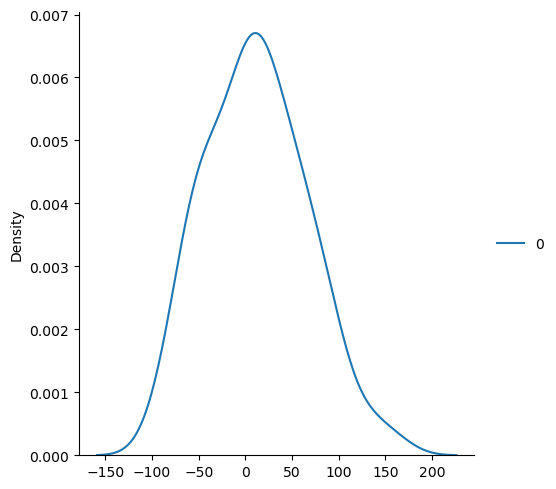

In [11]:
y_residual = y_test - y_pred

sns.displot(y_residual,kind='kde')

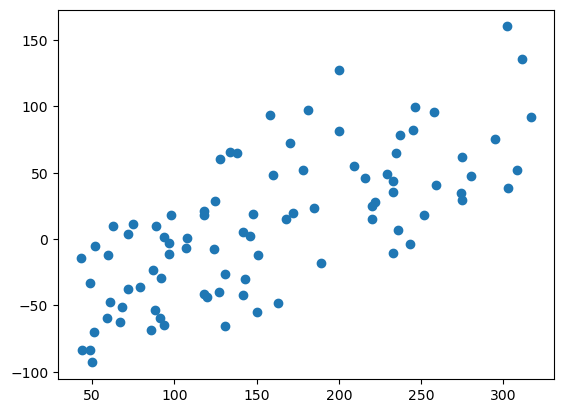

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_residual)

In [13]:
y_train = y_train.values.ravel()
# np.ones(10).shape

In [14]:
# Linear Regression using Batch Gradient Descent:
class GDRegressor():
    def __init__(self,epochs,alpha):
        
        self.epochs_ = epochs
        self.alpha_ = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        rows, cols = X_train.shape[0], X_train.shape[1]
        self.coef_ = np.ones(cols)
        self.intercept_ = 0
        
        for i in range(self.epochs_):
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            slope_intercept = (-2)*(np.mean(y_train - y_hat))
            slope_coef = (-2/rows)*(np.dot(X_train.T,y_train-y_hat))
            
            self.intercept_ -= self.alpha_*slope_intercept
            self.coef_ -= self.alpha_*slope_coef
            
    def predict(self,X):
        
        return np.dot(X,self.coef_) + self.intercept_

In [15]:
model = GDRegressor(epochs=1000,alpha=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test,y_pred)}")

print("Learned slope:", model.coef_)
print("Learned intercept:", model.intercept_)

R2 Score: 0.48922500373641975
Learned slope: [  53.92177046 -200.90632366  469.80466103  307.89638336  -63.31604746
 -108.85992261 -228.01773826  116.05965743  387.28699152  138.17673214]
Learned intercept: 149.74308858087787


In [16]:
mr = LinearRegression()
mr.fit(X_train,y_train)
y_pred = mr.predict(X_test)
print(f"R2 Score: {r2_score(y_test,y_pred)}")

print("Learned slope:", mr.coef_)
print("Learned intercept:", mr.intercept_)

R2 Score: 0.5002472361041004
Learned slope: [  44.19355716 -240.02129399  490.28738283  331.88852968 -785.79400259
  487.64421138   35.19787855  112.93618404  727.171488     91.00554753]
Learned intercept: 149.79906394666295


In [29]:
# Linear Regression using Stochastic Gradient Descent:
class SGDRegressor():
    def __init__(self,epochs,alpha):
        
        self.epochs_ = epochs
        self.alpha_ = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        rows, cols = X_train.shape[0], X_train.shape[1]
        self.coef_ = np.ones(cols)
        self.intercept_ = 0
        
        for i in range(self.epochs_):
            for j in range(rows):
                idx = np.random.randint(0,rows)
                y_hat = np.dot(X_train.iloc[idx,:],self.coef_) + self.intercept_
                
                slope_intercept = (-2)*(y_train[idx] - y_hat)
                slope_coef = (-2)*(np.dot(X_train.iloc[idx,:],y_train[idx]-y_hat))
                
                self.intercept_ -= self.alpha_*slope_intercept
                self.coef_ -= self.alpha_*slope_coef
            
    def predict(self,X):
        
        return np.dot(X,self.coef_) + self.intercept_

In [32]:
model2 = SGDRegressor(epochs=100,alpha=0.5)
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
print(f"R2 Score: {r2_score(y_test,y_pred)}")

print("Learned slope:", model2.coef_)
print("Learned intercept:", model2.intercept_)

R2 Score: 0.4264800560044122
Learned slope: [ -16.11246244 -200.61849429  595.7078384   298.95161828 -411.05160603
  218.8717982  -184.86572759  137.70531032  571.63043937  172.19684219]
Learned intercept: 185.906074693858


In [46]:
# Linear Regression using Mini Batch Gradient Descent:
import random
class MBGDRegressor():
    def __init__(self,epochs,alpha,batch_size):
        
        self.epochs_ = epochs
        self.alpha_ = alpha
        self.batch_size = batch_size
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        rows, cols = X_train.shape[0], X_train.shape[1]
        self.coef_ = np.ones(cols)
        self.intercept_ = 0
        
        for i in range(self.epochs_):
            for j in range(rows//self.batch_size):
                idx = random.sample(range(rows),self.batch_size)
                y_hat = np.dot(X_train.iloc[idx,:],self.coef_) + self.intercept_
                
                slope_intercept = (-2)*np.mean(y_train[idx] - y_hat)
                slope_coef = (-2/self.batch_size)*(np.dot(y_train[idx]-y_hat,X_train.iloc[idx,:]))
                
                self.intercept_ -= self.alpha_*slope_intercept
                self.coef_ -= self.alpha_*slope_coef
            
    def predict(self,X):
        
        return np.dot(X,self.coef_) + self.intercept_

In [47]:
model3 = MBGDRegressor(epochs=100,alpha=0.5,batch_size=32)
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)
print(f"R2 Score: {r2_score(y_test,y_pred)}")

print("Learned slope:", model3.coef_)
print("Learned intercept:", model3.intercept_)

R2 Score: 0.5137371444596099
Learned slope: [  46.27160625 -210.30571273  471.59056536  315.79000514  -55.16241615
 -105.05537295 -220.29527092  101.26101047  403.53645676  133.55776625]
Learned intercept: 165.56733754735063
